# Lecture 1: Introduction to Data Science
**BITE 485 | Tharaka University**

---

## Learning Outcomes
By the end of this notebook you should be able to:
1. Define data science and describe the data science workflow
2. Use core Python data science libraries
3. Load, inspect, and describe a dataset
4. Classify a problem as classification, regression, or clustering

## 1.1 The Python Data Science Stack

The following imports are the standard starting point for almost every data science project.

In [17]:
# Standard data science imports — run this cell first
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')
print('Libraries loaded successfully.')

Libraries loaded successfully.


## 1.2 Generating and Inspecting a Dataset

We will use the classic Iris dataset as our first exploration target. It contains 150 flower measurements across 3 species.

In [16]:
# Load and convert to DataFrame
iris = load_iris(as_frame=True)
df = iris.frame
df['species'] = df['target'].map({0: 'setosa', 1: 'versicolor', 2: 'virginica'})
df.drop(columns=['target'], inplace=True)

print(f'Shape: {df.shape}')
print(f'\nColumn names: {list(df.columns)}')
df.head(10)

Shape: (150, 5)

Column names: ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)', 'species']


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.100,3.500,1.400,0.200,setosa
1,4.900,3.000,1.400,0.200,setosa
2,4.700,3.200,1.300,0.200,setosa
3,4.600,3.100,1.500,0.200,setosa
4,5.000,3.600,1.400,0.200,setosa
5,5.400,3.900,1.700,0.400,setosa
6,4.600,3.400,1.400,0.300,setosa
7,5.000,3.400,1.500,0.200,setosa
8,4.400,2.900,1.400,0.200,setosa
9,4.900,3.100,1.500,0.100,setosa


In [15]:
# Summary statistics
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000,150.000,150.000,150.000
mean,5.843,3.057,3.758,1.199
std,0.828,0.436,1.765,0.762
min,4.300,2.000,1.000,0.100
25%,5.100,2.800,1.600,0.300
50%,5.800,3.000,4.350,1.300
75%,6.400,3.300,5.100,1.800
max,7.900,4.400,6.900,2.500


In [14]:
# Missing values check
print('Missing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')

Missing values per column:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Duplicate rows: 1


## 1.3 The Data Science Workflow

Every data science project moves through these phases:

| Phase | Question Asked | Output |
|---|---|---|
| Problem Definition | What are we trying to solve? | Problem statement |
| Data Collection | What data do we have? | Raw dataset |
| Data Cleaning | Is the data ready? | Clean dataset |
| EDA | What patterns exist? | Visualisations, hypotheses |
| Modelling | What algorithm fits? | Trained model |
| Evaluation | How good is it? | Metrics |
| Deployment | How do we use it? | Production system |
| Monitoring | Is it still working? | Performance logs |

## 1.4 Quick Visual EDA

/tmp/ipykernel_12426/1602473618.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='species', y='petal length (cm)', ax=axes[0], palette='Set2')


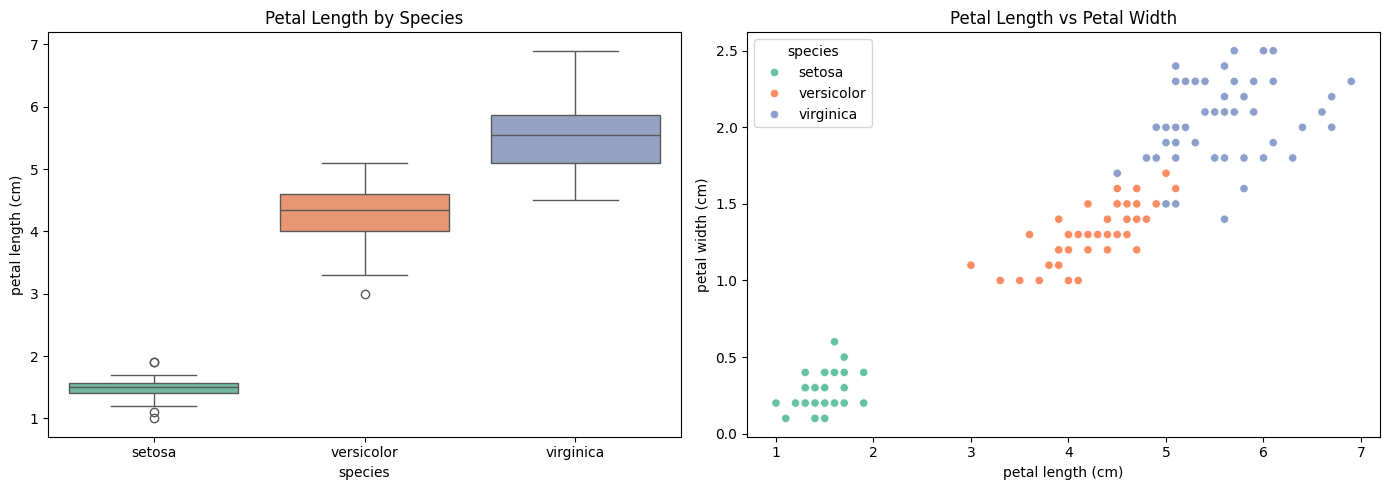

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of petal length by species
sns.boxplot(data=df, x='species', y='petal length (cm)', ax=axes[0], palette='Set2')
axes[0].set_title('Petal Length by Species')

# Scatter: petal length vs petal width
sns.scatterplot(data=df, x='petal length (cm)', y='petal width (cm)',
                hue='species', palette='Set2', ax=axes[1])
axes[1].set_title('Petal Length vs Petal Width')

plt.tight_layout()
plt.show()

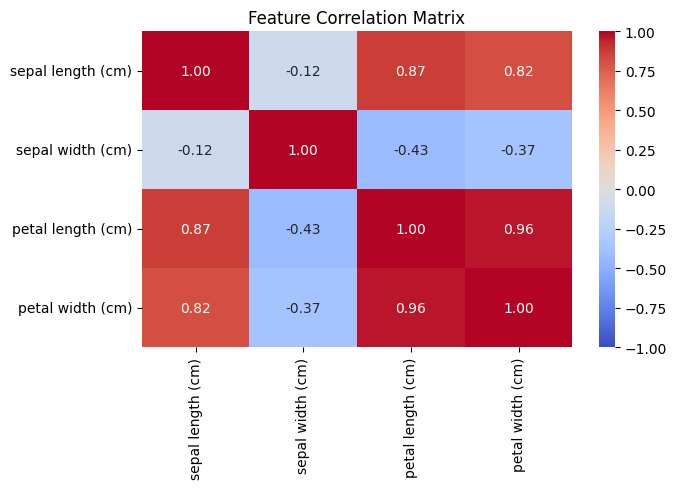

In [10]:
# Correlation matrix
plt.figure(figsize=(7, 5))
sns.heatmap(df.drop(columns='species').corr(), annot=True, fmt='.2f',
            cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## 1.5 Problem Type Classification

| Problem | Type | Why |
|---|---|---|
| Predict species from measurements | Classification | Output is a discrete label |
| Predict petal length from other features | Regression | Output is a continuous number |
| Group similar flowers without labels | Clustering | No predefined classes |

### Exercise

Using the Iris DataFrame:
1. Print the value counts of each species.
2. Plot a histogram of `sepal length (cm)` with 15 bins.
3. Calculate the mean petal width for each species using `groupby`.

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


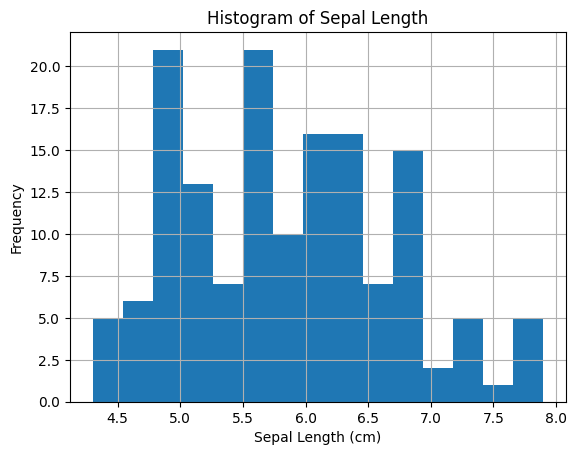

species
setosa       0.246
versicolor   1.326
virginica    2.026
Name: petal width (cm), dtype: float64


In [19]:
# Your code here
# 1. Print the value counts of each species
print(df['species'].value_counts())

# 2. Plot a histogram of sepal length (cm) with 15 bins
import matplotlib.pyplot as plt

df['sepal length (cm)'].hist(bins=15)
plt.title('Histogram of Sepal Length')
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Frequency')
plt.show()

# 3. Calculate the mean petal width for each species using groupby
mean_petal_width = df.groupby('species')['petal width (cm)'].mean()
print(mean_petal_width)

---
*BITE 485 Data Science | Tharaka University | kevin.tuei@tharaka.ac.ke*